In [1]:
import pandas as pd

In [2]:
import seaborn as sns

In [3]:
import matplotlib.pyplot as plt

In [5]:
bitcoin = pd.read_csv("fear_greed_index.csv")
historical = pd.read_csv("historical_data.csv")

In [6]:
print(bitcoin.head())
print(historical.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [11]:
print(f"bitcoin Data: {bitcoin.shape[0]} rows, {bitcoin.shape[1]} columns")
print(f"historical Data: {historical.shape[0]} rows, {historical.shape[1]} columns")

bitcoin Data: 2644 rows, 4 columns
historical Data: 211224 rows, 16 columns


In [12]:
#check for missing values
print("\nMissing values in bitcoin:\n", bitcoin.isnull().sum())
print("\nMissing values in historical:\n", historical.isnull().sum())


Missing values in bitcoin:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in historical:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [13]:
#Convert fear_greed_index date 
bitcoin['Date'] = pd.to_datetime(bitcoin['date'])
#convert historical_data timestamps to daily dates
historical['Date'] = pd.to_datetime(historical['Timestamp'], unit='ms').dt.normalize()

In [16]:
#merge the data
df=pd.merge(bitcoin, historical, on = 'Date', how= 'left')

In [17]:
# PART B 
#check profitability
analysis = df.groupby('classification')['Closed PnL'].mean()
print(analysis)

classification
Extreme Fear           NaN
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64


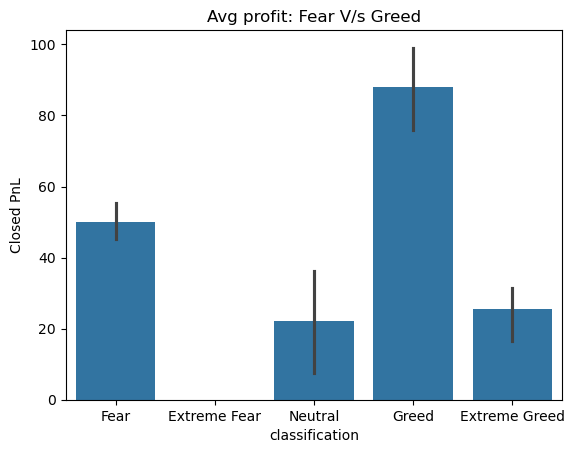

In [18]:
#visualisation
sns.barplot(data=df, x='classification', y='Closed PnL')
plt.title('Avg profit: Fear V/s Greed')
plt.show()

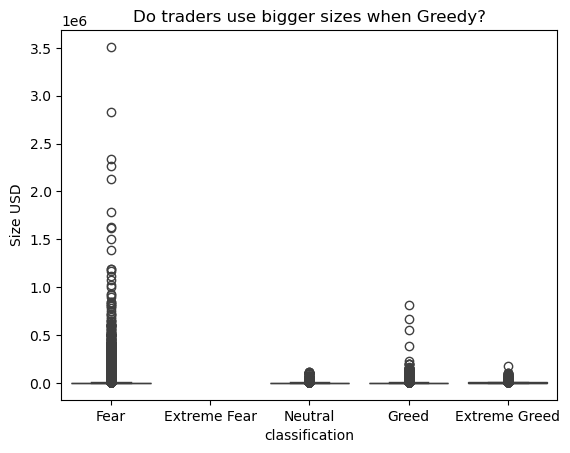

In [21]:
# We use 'classification' and 'Size USD' because those exist in your data
sns.boxplot(data=df, x='classification', y='Size USD')
plt.title('Do traders use bigger sizes when Greedy?')
plt.show()

In [23]:
# 1. Create a summary table for every unique Account
trader_summary = df.groupby('Account').agg({
    'Closed PnL': 'mean',
    'Size USD': 'mean',
    'Trade ID': 'count' # This counts how many trades they made
}).rename(columns={'Trade ID': 'trade_count', 'Closed PnL': 'avg_pnl'})

# 2. Define the 'Average' activity level
avg_activity = trader_summary['trade_count'].mean()

# 3. Label them based on that average
trader_summary['frequency_segment'] = trader_summary['trade_count'].apply(
    lambda x: 'Frequent' if x > avg_activity else 'Infrequent'
)

print(f"Average trades per account: {avg_activity:.2f}")
print(trader_summary['frequency_segment'].value_counts())

Average trades per account: 5758.22
frequency_segment
Infrequent    22
Frequent      10
Name: count, dtype: int64


C:\Users\ashib\AppData\Local\Temp\ipykernel_23264\376543505.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=trader_summary, x='performance_segment', palette='viridis')


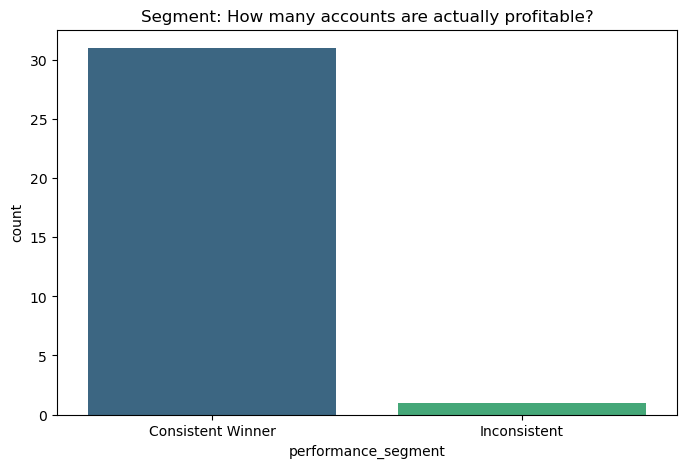

In [24]:
# 1. Label traders as 'Winner' if their average PnL is positive (> 0)
trader_summary['performance_segment'] = trader_summary['avg_pnl'].apply(
    lambda x: 'Consistent Winner' if x > 0 else 'Inconsistent'
)

# 2. Visualize the results
plt.figure(figsize=(8, 5))
sns.countplot(data=trader_summary, x='performance_segment', palette='viridis')
plt.title('Segment: How many accounts are actually profitable?')
plt.show()

In [25]:
# Merge the segment labels back into the main data
df = df.merge(trader_summary[['frequency_segment', 'performance_segment']], on='Account', how='left')

# Compare Average Profit by Frequency and Sentiment
pivot_analysis = df.pivot_table(
    values='Closed PnL', 
    index='classification', 
    columns='frequency_segment', 
    aggfunc='mean'
)

print("Average PnL by Sentiment and Frequency:")
print(pivot_analysis)

Average PnL by Sentiment and Frequency:
frequency_segment   Frequent  Infrequent
classification                          
Extreme Greed      26.658319  -48.382749
Fear               26.212864  110.287033
Greed              80.909079  132.070928
Neutral             4.058759  351.937527
